# Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving USA.xlsx to USA.xlsx


In [3]:
df = pd.read_excel("USA.xlsx")


In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 25 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Country  6019 non-null   object        
 1   League   6019 non-null   object        
 2   Season   6019 non-null   int64         
 3   Date     6019 non-null   datetime64[ns]
 4   Time     6019 non-null   object        
 5   Home     6019 non-null   object        
 6   Away     6019 non-null   object        
 7   HG       6019 non-null   int64         
 8   AG       6019 non-null   int64         
 9   Res      6019 non-null   object        
 10  PSCH     5800 non-null   float64       
 11  PSCD     5800 non-null   float64       
 12  PSCA     5800 non-null   float64       
 13  MaxCH    6019 non-null   float64       
 14  MaxCD    6019 non-null   float64       
 15  MaxCA    6019 non-null   float64       
 16  AvgCH    6019 non-null   object        
 17  AvgCD    6019 non-null   float64 

,Country,League,Season,Date,Time,Home,Away,HG,AG,Res,...,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA,B365CH,B365CD,B365CA
0,USA,MLS,2012,2012-03-10,23:00:00,Colorado Rapids,Columbus Crew,2,0,H,...,4.11,2.01,3.19,3.65,NaN,NaN,NaN,NaN,NaN,NaN
1,USA,MLS,2012,2012-03-10,23:00:00,Vancouver Whitecaps,CF Montreal,2,0,H,...,4.11,1.97,3.27,3.70,NaN,NaN,NaN,NaN,NaN,NaN
2,USA,MLS,2012,2012-03-11,00:30:00,DC United,Sporting Kansas City,0,1,A,...,3.04,2.46,3.11,2.81,NaN,NaN,NaN,NaN,NaN,NaN
3,USA,MLS,2012,2012-03-11,03:30:00,Los Angeles Galaxy,Real Salt Lake,1,3,A,...,5.00,1.81,3.33,4.31,NaN,NaN,NaN,NaN,NaN,NaN
4,USA,MLS,2012,2012-03-11,03:30:00,San Jose Earthquakes,New England Revolution,1,0,H,...,5.00,1.82,3.36,4.23,NaN,NaN,NaN,NaN,NaN,NaN


# Check missing values

In [5]:
df.isnull().sum()

,0
Country,0
League,0
Season,0
Date,0
Time,0
Home,0
Away,0
HG,0
AG,0
Res,0


# Remove duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

# Focus analysis columns

In [7]:
analysis_df = df[
    [
        "Season",
        "Date",
        "Home",
        "Away",
        "HG",
        "AG",
        "Res",
        "PSCH",
        "PSCD",
        "PSCA"
    ]
]

In [8]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Season  6019 non-null   int64         
 1   Date    6019 non-null   datetime64[ns]
 2   Home    6019 non-null   object        
 3   Away    6019 non-null   object        
 4   HG      6019 non-null   int64         
 5   AG      6019 non-null   int64         
 6   Res     6019 non-null   object        
 7   PSCH    5800 non-null   float64       
 8   PSCD    5800 non-null   float64       
 9   PSCA    5800 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 470.4+ KB


# Data Description
| Column   | Data Type     | Description                                                         |
| -------- | ------------- | ------------------------------------------------------------------- |
| `Season` | Integer       | MLS season year in which the match was played                       |
| `Date`   | Datetime      | Date the match was played                                           |
| `Home`   | Object/String | Home team name                                                      |
| `Away`   | Object/String | Away team name                                                      |
| `HG`     | Integer       | Number of goals scored by the home team                             |
| `AG`     | Integer       | Number of goals scored by the away team                             |
| `Res`    | Object/String | Full-time match result (`H` = Home Win, `D` = Draw, `A` = Away Win) |
| `PSCH`   | Float         | Pinnacle odds for a home team win                                   |
| `PSCD`   | Float         | Pinnacle odds for a draw                                            |
| `PSCA`   | Float         | Pinnacle odds for an away team win                                  |


Betfair Exchange and Bet365 odds were excluded from the main analysis due to substantial missing values, which could reduce statistical reliability

In [9]:
analysis_df[analysis_df["PSCH"].isnull()]

,Season,Date,Home,Away,HG,AG,Res,PSCH,PSCD,PSCA
3034,2020,2020-08-22,Toronto FC,Vancouver Whitecaps,1,0,H,NaN,NaN,NaN
5789,2025,2025-10-26,Philadelphia Union,Chicago Fire,2,2,D,NaN,NaN,NaN
5791,2025,2025-10-27,San Diego FC,Portland Timbers,2,1,H,NaN,NaN,NaN
5796,2025,2025-11-01,New York City,Charlotte,0,0,D,NaN,NaN,NaN
5797,2025,2025-11-01,Chicago Fire,Philadelphia Union,0,3,A,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6014,2026,2026-05-17,Real Salt Lake,Colorado Rapids,2,1,H,NaN,NaN,NaN
6015,2026,2026-05-17,San Diego FC,FC Cincinnati,3,3,D,NaN,NaN,NaN
6016,2026,2026-05-17,San Jose Earthquakes,FC Dallas,2,3,A,NaN,NaN,NaN
6017,2026,2026-05-17,Inter Miami,Portland Timbers,2,0,H,NaN,NaN,NaN


In [10]:
analysis_df = analysis_df.dropna(
    subset=["PSCH", "PSCD", "PSCA"]
)

In [11]:
analysis_df.info()
analysis_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5800 entries, 0 to 5815
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Season  5800 non-null   int64         
 1   Date    5800 non-null   datetime64[ns]
 2   Home    5800 non-null   object        
 3   Away    5800 non-null   object        
 4   HG      5800 non-null   int64         
 5   AG      5800 non-null   int64         
 6   Res     5800 non-null   object        
 7   PSCH    5800 non-null   float64       
 8   PSCD    5800 non-null   float64       
 9   PSCA    5800 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 498.4+ KB


,Season,Date,Home,Away,HG,AG,Res,PSCH,PSCD,PSCA
0,2012,2012-03-10,Colorado Rapids,Columbus Crew,2,0,H,2.06,3.40,4.11
1,2012,2012-03-10,Vancouver Whitecaps,CF Montreal,2,0,H,2.04,3.44,4.11
2,2012,2012-03-11,DC United,Sporting Kansas City,0,1,A,2.57,3.31,3.04
3,2012,2012-03-11,Los Angeles Galaxy,Real Salt Lake,1,3,A,1.88,3.57,4.88
4,2012,2012-03-11,San Jose Earthquakes,New England Revolution,1,0,H,1.83,3.65,4.95


# Business Question 1
⚽ How Accurate Is the MLS Betting Market at Predicting Match Outcomes?

# Create Market Prediction

In [12]:
def market_prediction(row):

    lowest_odds = min(row["PSCH"], row["PSCD"], row["PSCA"])

    if lowest_odds == row["PSCH"]:
        return "H"

    elif lowest_odds == row["PSCD"]:
        return "D"

    else:
        return "A"

analysis_df["Market_Prediction"] = analysis_df.apply(
    market_prediction,
    axis=1
)

# Compare Market Prediction vs Actual Result

In [13]:
analysis_df["Correct_Prediction"] = (
    analysis_df["Market_Prediction"] == analysis_df["Res"]
)

In [14]:
market_accuracy = (
    analysis_df["Correct_Prediction"]
    .mean() * 100
)

print(f"Market Accuracy: {market_accuracy:.2f}%")

Market Accuracy: 50.66%


The MLS betting market shows moderate predictive power, correctly forecasting match outcomes in 50.66% of cases. This indicates that while bookmakers incorporate strong information into odds, the league remains sufficiently unpredictable that nearly half of all matches deviate from market expectations.

# Business Question 2
⚽ Has Home Advantage in MLS Changed Over Time?

# Step 1 — Create Home Win Indicator

In [15]:
analysis_df["Home_Win"] = (analysis_df["Res"] == "H").astype(int)

# Step 2 — Calculate Home Win Rate by Season

In [16]:
home_advantage_trend = analysis_df.groupby("Season")["Home_Win"].mean() * 100

print(home_advantage_trend)

Season
2012    51.479290
2013    50.887574
2014    48.520710
2015    54.341737
2016    50.700280
2017    54.987212
2018    54.166667
2019    52.019002
2020    47.058824
2021    47.669492
2022    49.079755
2023    48.176583
2024    45.019157
2025    44.190476
Name: Home_Win, dtype: float64


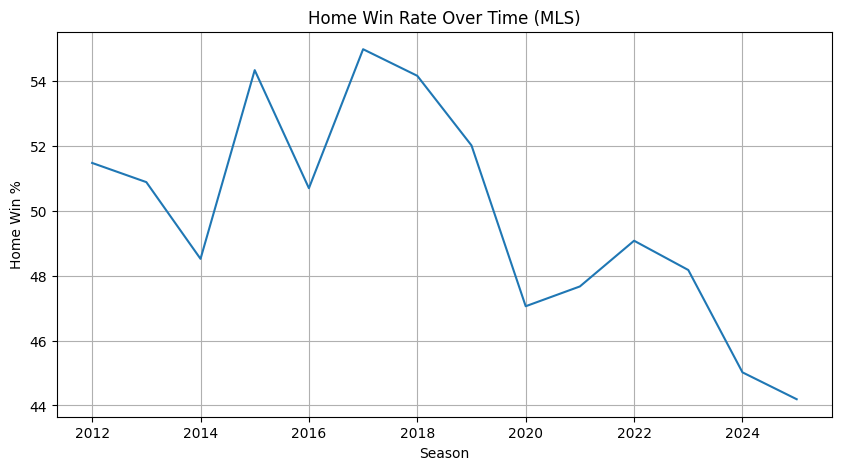

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(home_advantage_trend.index, home_advantage_trend.values)

plt.title("Home Win Rate Over Time (MLS)")
plt.xlabel("Season")
plt.ylabel("Home Win %")
plt.grid(True)
plt.show()

Home advantage in MLS has significantly weakened over time. While home teams previously won more than half of their matches before 2020, recent seasons show a consistent decline, with home win rates dropping below 50%. This indicates a structural shift toward greater competitive balance and reduced home-field dominance

# Business Question 3
⚽ Which MLS Teams Consistently Outperform Betting Market Expectations?

# Step 1 — Create Prediction Success Indicator

In [18]:
analysis_df["Market_Correct"] = (
    analysis_df["Market_Prediction"] == analysis_df["Res"]
).astype(int)

# Step 2 — Create Team-Level Match Records

In [19]:
home_df = analysis_df[[
    "Season",
    "Home",
    "Res",
    "Market_Prediction",
    "Market_Correct"
]].copy()

home_df.rename(columns={"Home": "Team"}, inplace=True)

away_df = analysis_df[[
    "Season",
    "Away",
    "Res",
    "Market_Prediction",
    "Market_Correct"
]].copy()

away_df.rename(columns={"Away": "Team"}, inplace=True)

team_df = pd.concat([home_df, away_df])

# Step 3 — Identify When Teams Beat Market Expectations

In [21]:
team_df.head()

,Season,Team,Res,Market_Prediction,Market_Correct
0,2012,Colorado Rapids,H,H,1
1,2012,Vancouver Whitecaps,H,H,1
2,2012,DC United,A,H,0
3,2012,Los Angeles Galaxy,A,H,0
4,2012,San Jose Earthquakes,H,H,1


# Step 4 — Create Team Win Indicator

In [20]:
analysis_df["Home_Win"] = (analysis_df["Res"] == "H").astype(int)
analysis_df["Away_Win"] = (analysis_df["Res"] == "A").astype(int)

# Step 5 — Build Team Performance Table

In [22]:
home_performance = pd.DataFrame({
    "Team": analysis_df["Home"],
    "Win": analysis_df["Home_Win"],
    "Market_Correct": analysis_df["Market_Correct"]
})

away_performance = pd.DataFrame({
    "Team": analysis_df["Away"],
    "Win": analysis_df["Away_Win"],
    "Market_Correct": analysis_df["Market_Correct"]
})

team_performance = pd.concat([
    home_performance,
    away_performance
])

# Step 6 — Calculate Outperformance Metric

In [23]:
team_performance["Beat_Market"] = (
    (team_performance["Win"] == 1) &
    (team_performance["Market_Correct"] == 0)
).astype(int)

In [24]:
team_market_outperformance = (
    team_performance.groupby("Team")
    .agg(
        Matches=("Win", "count"),
        Wins=("Win", "sum"),
        Beat_Market=("Beat_Market", "sum")
    )
)

team_market_outperformance["Beat_Market_Rate"] = (
    team_market_outperformance["Beat_Market"]
    / team_market_outperformance["Matches"]
) * 100

team_market_outperformance = (
    team_market_outperformance
    .sort_values("Beat_Market_Rate", ascending=False)
)

team_market_outperformance.head(10)

,Matches,Wins,Beat_Market,Beat_Market_Rate
Team,,,,
San Diego FC,36,20,7,19.444444
Vancouver Whitecaps,483,179,84,17.391304
Minnesota United,307,116,53,17.263844
Charlotte,141,56,24,17.021277
Inter Miami,202,88,33,16.336634
Austin FC,174,60,28,16.091954
Chivas USA,102,22,16,15.686275
FC Cincinnati,239,89,37,15.481172
CF Montreal,479,171,69,14.405010


Several MLS clubs consistently outperform betting market expectations, with Vancouver Whitecaps and Minnesota United showing particularly strong long-term records of winning matches the market did not predict. This suggests that certain teams possess characteristics or tactical strengths that are not fully captured by bookmaker pricing models.

# Business Question 4
⚽ Are MLS Matches Becoming More Unpredictable Over Time?

# Step 1 — Calculate Seasonal Market Accuracy

In [25]:
season_accuracy = (
    analysis_df.groupby("Season")["Correct_Prediction"]
    .mean() * 100
)

print(season_accuracy)

Season
2012    53.254438
2013    52.958580
2014    50.295858
2015    52.100840
2016    49.859944
2017    54.731458
2018    55.147059
2019    54.394299
2020    49.845201
2021    49.152542
2022    48.261759
2023    47.024952
2024    46.168582
2025    49.904762
Name: Correct_Prediction, dtype: float64


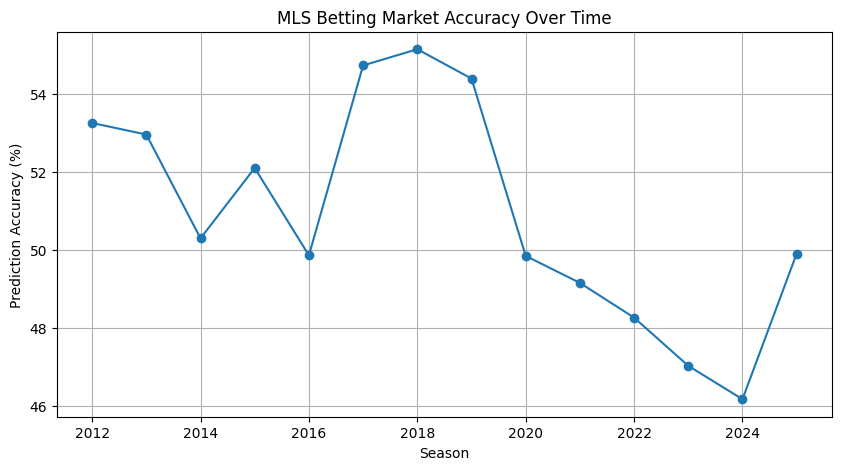

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    season_accuracy.index,
    season_accuracy.values,
    marker="o"
)

plt.title("MLS Betting Market Accuracy Over Time")
plt.xlabel("Season")
plt.ylabel("Prediction Accuracy (%)")

plt.grid(True)

plt.show()

MLS matches have become more unpredictable over time. Betting market accuracy declined significantly after 2020, indicating that match outcomes are increasingly difficult to forecast. This suggests growing competitive balance, weaker structural advantages, and higher volatility across the league.

# Business Question 5
⚽ Which Betting Odds Ranges Produce the Highest Upset Frequency?

# Step 1 — Identify Favorite Odds

In [27]:
analysis_df["Upset"] = (
    analysis_df["Correct_Prediction"] == False
).astype(int)

In [28]:
analysis_df["Favorite_Odds"] = analysis_df[
    ["PSCH", "PSCD", "PSCA"]
].min(axis=1)

# Step 2 — Create Odds Ranges

In [29]:
bins = [1, 1.5, 2.0, 2.5, 3.0, 5.0]

labels = [
    "1.0–1.5",
    "1.5–2.0",
    "2.0–2.5",
    "2.5–3.0",
    "3.0+"
]

analysis_df["Odds_Range"] = pd.cut(
    analysis_df["Favorite_Odds"],
    bins=bins,
    labels=labels
)

In [30]:
upset_analysis = (
    analysis_df.groupby("Odds_Range")
    .agg(
        Matches=("Upset", "count"),
        Upsets=("Upset", "sum")
    )
)

upset_analysis["Upset_Rate"] = (
    upset_analysis["Upsets"]
    / upset_analysis["Matches"]
) * 100

print(upset_analysis)

            Matches  Upsets  Upset_Rate
Odds_Range                             
1.0–1.5         465     137   29.462366
1.5–2.0        2517    1098   43.623361
2.0–2.5        2250    1269   56.400000
2.5–3.0         568     358   63.028169
3.0+              0       0         NaN


/tmp/ipykernel_3679/2479704252.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("Odds_Range")


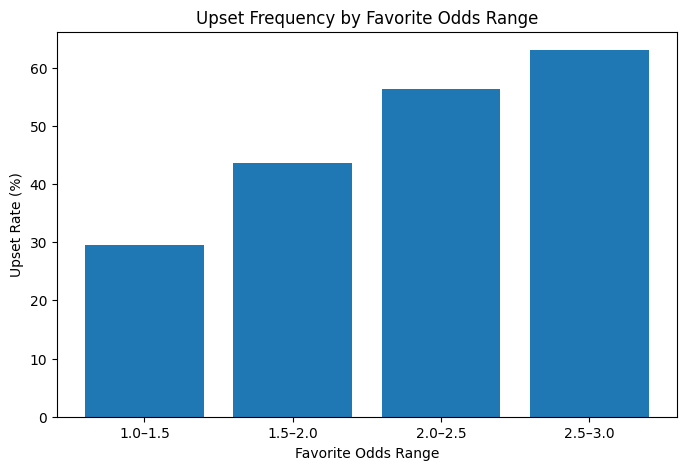

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    upset_analysis.index.astype(str),
    upset_analysis["Upset_Rate"]
)

plt.title("Upset Frequency by Favorite Odds Range")
plt.xlabel("Favorite Odds Range")
plt.ylabel("Upset Rate (%)")

plt.show()

Upset frequency in MLS rises substantially as betting odds become more balanced. Strong favorites with low odds are relatively reliable, while matches with favorite odds above 2.0 become highly volatile, with upset rates exceeding 56%. This indicates that MLS unpredictability is concentrated primarily in evenly matched contests.